# 01 · Acquisition and tracking

Notebook `00` confirmed the collect is usable. This one despreads it: **acquisition**
finds which satellites are present and roughly where, **tracking** follows them.

Correlating against a satellite's PRN code gives processing gain of about
`10·log10(T · R_c)` — 47 dB for 5 ms of a 10.23 Mcps code — which is what lifts a
signal from tens of dB below the noise floor into a visible peak. That gain only
accrues if two unknowns are right:

| Unknown | Why it is unknown | Grid resolution |
|---|---|---|
| **Code phase** | the code delay it implies is proportional to range (§7.2) | one sample |
| **Doppler** | line-of-sight velocity, ±5 kHz for a static receiver | one FFT bin, `1 / T_replica` |

Acquisition searches that 2-D grid (FFT-based parallel code-phase search across a
Doppler bank) and thresholds the peak against a chi-squared noise model. Tracking
closes loops around the result: a DLL on early/late correlators for code phase, an
FLL then a PLL for carrier. Both unknowns drift as the satellite moves, which is why
tracking is a loop rather than a repeated search.

## The four GPS civil signals

All four are implemented; `SIGNAL_ID` in section 2 chooses one.

| | GPS L1 C/A | GPS L2C | GPS L5 | GPS L1C |
|---|---|---|---|---|
| **Band** | L1, 1575.42 MHz | L2, 1227.60 MHz | L5, 1176.45 MHz | L1, 1575.42 MHz |
| **Components** | `CA` | `CM`, `CL` | `I`, `Q` | `L1CD`, `L1CP` |
| **Chip rate** | 1.023 Mcps | 511.5 kcps each | 10.23 Mcps each | 1.023 Mcps |
| **Primary code period** | 1 ms | CM 20 ms, CL 1.5 s | 1 ms | 10 ms |
| **Modulation** | BPSK(1) | BPSK(1), chip-interleaved | BPSK(10), I/Q quadrature | L1CD BOC(1,1), L1CP TMBOC(6,1,4/33) |
| **Data** | 50 bps, 20 ms symbols on `CA` | 50 sps, 20 ms symbols on `CM` | 100 sps, 10 ms symbols on `I` | 100 sps, 10 ms symbols on `L1CD` |
| **Pilot** | none | `CL` | `Q` | `L1CP` |
| **Overlay code** | none | none | NH10 on `I`, NH20 on `Q` | 1800-chip, 18 s, on `L1CP` |
| **Carrier loop runs on** | `CA` | `CM`, then `CL` | `Q` | `L1CP` |

**Terms.** A *component* is one spreading code within a signal. A *pilot* carries no
data, so the carrier loop can use a four-quadrant discriminator instead of a Costas one
— worth about 6 dB. An *overlay* code multiplies each primary code period by one further
chip; until it is synchronised it flips sign like data and caps coherent integration at
one primary period. A *subcarrier* is a square wave riding **inside** each chip, present
from the first sample and needing no synchronising.

**BOC.** The first three signals are BPSK — each chip is a flat ±1. L1C multiplies every
chip by a subcarrier, splitting its power into two lobes either side of the carrier so
it can share L1 with C/A without sitting on top of it. BOC(n,1) divides each chip into
`2n` alternating sub-chips; TMBOC(6,1,4/33) uses BOC(6,1) on 4 chips of every 33 and
BOC(1,1) on the other 29. The consequence — a narrower peak, flanked by side peaks a
delay loop can lock onto — is section 6.3.

> **Design note.** A signal is described by data, not by a bespoke correlator, so one
> `TrackingChannel` serves every signal: `utils.code_components` says how each code
> occupies the chip clock, a `LoopDiscriminatorPolicy` says which component drives which
> loop, and `ACQUISITION_POLICIES` / `TRACKING_POLICIES` hold the policy separately.

## 1. Imports

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import utils
from utils import (
    bpsk_acquisition,
    catalog,
    sample_streaming,
    tables,
    tracking_channel,
    tracking_io,
)
from utils.signal_interfaces import (
    GpsL1C,
    GpsL1CA,
    GpsL2C,
    GpsL5,
    build_acquisition_code_params,
    build_signals,
    create_tracking_channels,
    resolve_acquisition_ambiguities,
)

import importlib
importlib.reload(utils.tracking_io)

utils.plotting.setup_default_plotting()

## 2. Configuration

### 2.1 Which signal, and which collect

`SIGNAL_ID` comes first because it fixes the band, and the band fixes which
recordings can be used at all:

| Band | Signals |
|---|---|
| L1 | `GpsL1CA`, `GpsL1C` |
| L2 | `GpsL2C` |
| L5 | `GpsL5` |

The next cell then lists only the collects carrying that band. Set
`EXPERIMENT_INDEX` from its `exp` column; the collect within the experiment is not
a knob, since the signal already determines which one carries its band.

Two things the table is worth checking before running anything:

- **Sample rate against chip rate.** The correlator advances its chip index once per
  sample, so below about two samples per chip it silently skips chips. A 10.23 Mcps
  signal needs ≳ 20 Msps; a 1.023 Mcps signal needs only ~5. Section 3 checks this
  and refuses rather than producing nonsense.
- **Duration against `START_OFFSET_MS + TRACK_DURATION_MS`.** Section 3 prints what
  remains after the offset and warns if tracking will hit end of file.

In [2]:
SIGNAL_ID = GpsL1CA  # GpsL1CA, GpsL2C, GpsL5, or GpsL1C

collects_dir = utils.environment_variables.get_collects_path()
print(f"{SIGNAL_ID.signal_type_id} rides on band {SIGNAL_ID.link.id.value}\n")
catalog.print_collect_catalog(collects_dir, band=SIGNAL_ID.link.id.value);

GPS_L1CA rides on band L1

Collects under /Volumes/JX_SSD/Desktop/CU_Boulder/Summer_2026/HERON/COLLECTS, carrying band L1:
  exp  experiment                 ch  collect  band  Msps  fmt  IF [kHz]  dur [s]   GB
  ---  -------------------------  --  -------  ----  ----  ---  --------  -------  ---
    0  20210611_121000_011501_HI   2  RX7      L1     5.0  sc8         0      600  6.0
    1  20210612_121000_011501_HI   2  RX7      L1     5.0  sc8         0      120  1.2


### 2.2 Where in the collect to start

`START_OFFSET_MS` skips that far into the file before anything is read, and both halves
honour it — the code phase and Doppler acquisition recovers describe *those* samples and
seed only what immediately follows. Two consequences:

- **Uptime is zero at the offset**, not at the start of the file. Absolute time comes
  from the decoded navigation message in notebook `02`.
- **The output file is named after the span it covers** — `RX7_GPS_L1CA_120-600s.h5`
  ran from 120 s in to 600 s. So an exploratory segment cannot overwrite a full-length
  run, and notebook `02` rebuilds the same name from the same two numbers.

A long collect is not uniform: gain, geometry and interference all change over a pass,
so a capture that acquires nothing at the start may acquire mid-file.

### 2.3 Acquisition: two coherent durations

| Parameter | |
|---|---|
| `coherent_duration_replica_ms` | length of the local replica, and so of the FFT |
| `coherent_duration_sample_ms` | how much live data enters one coherent sum — the coherent gain |
| `num_blocks` | how many such sums are combined by square law. Sign flips *between* blocks are harmless |

Conflating the first two is the usual source of confusion. They answer to two independent
constraints, neither of which knows about the other:

- **The replica is set by the code.** The correlation is circular, so the replica must be
  a whole number of periods of whatever code is being correlated against — a partial
  period matches the data against the wrong chips on the wraparound.
- **The sample length is set by the sign flips.** A coherent sum accrues gain only while
  the accumulated sign is constant, so it must not straddle a data symbol boundary or an
  un-stripped overlay chip, whichever is shorter. Acquisition does not know where those
  boundaries fall, so the block has to be short enough that one landing anywhere still
  leaves most blocks clean.

Whichever comes out larger sets the Doppler bin — how far apart the hypotheses sit:

    Doppler bin = 1 / max(T_sample, T_replica)

How fast the correlation falls off *between* those hypotheses is a separate thing, set
by `T_sample` alone. Whichever is larger also decides what happens to the data:

- `sample < replica` → **zero-padding**. The sum has to stay inside a symbol while the
  replica is stuck at a whole code period, so each block is padded up to the replica
  length — at the offset it actually occupied, so every block's peak lands at the same lag.
- `sample > replica` → **folding**. The block covers a whole number of replica periods and
  they are summed onto one window before the transform. Worth doing because a replica
  longer than one code period searches the same code phase over and over: against a 1 ms
  code, a 5 ms replica reports the same answer five times. Folding buys the longer coherent
  sum without that redundancy — a shorter FFT, a smaller grid to threshold, and a code
  phase reported in the one period it is actually ambiguous over.

Section 3 draws both.

**The defaults, and why each number is what it is:**

| Signal | Acquired on | Code period | `replica_ms` | `sample_ms` | |
|---|---|---|---|---|---|
| **L1 C/A** | `CA` | 1 ms | **1** | **5** | folded ×5 |
| **L2C** | `CM` | 20 ms | **20** | **5** | zero-padded |
| **L5** | `Q`, NH20 built in | 20 ms | **20** | **5** | zero-padded |
| **L1C** | `L1CP` | 10 ms | **10** | **5** | zero-padded |

- **L1 C/A** is the only one of the four whose code period is *shorter* than the thing
  that flips its sign — 1 ms of code under a 20 ms data bit — and therefore the only one
  that can fold at all. The replica is one 1023-chip period, the shortest unambiguous
  choice, and 5 ms of data folds onto it, comfortably inside the data bit.
- **L2C** acquires on `CM`, whose 20 ms code period *is* its CNAV symbol, so folding is
  shut out from both directions: the replica cannot be shorter than one period and the
  coherent sum cannot be longer than one symbol. A full-length 20 ms sum at an arbitrary
  alignment straddles a boundary; 5 ms blocks put at most one boundary in any one block.
- **L5** acquires on the `Q` pilot with NH20 built into the code, so the recovered code
  phase carries the NH20 counter outright. That makes the acquisition code 20 ms and the
  situation identical to L2C.
- **L1C** acquires on the pilot `L1CP`, whose 10 ms code period is both the minimum (a
  partial period would alias the code phase) and the maximum (L1CO flips the pilot's sign
  at exactly that rate), so the replica is pinned at 10; 5 ms blocks then keep clear of the
  overlay chip boundary. L1C's replica also carries **the subcarrier**, which it must:
  being odd-symmetric within a chip, the subcarrier makes a plain BPSK replica's two halves
  cancel and the peak collapse into the noise. Its **overlay** stays out — building L1CO in
  the way L5 builds in NH20 would need an 18-second replica — so L1C acquires modulo 10 ms
  and finds the overlay phase after lock, by FFT search.

`p_fa_total` is the false-alarm probability over the whole search grid, not per cell.

### 2.4 Fine search

`FineSearchParameters` refines each *detected* peak on a finer grid around it (`None`
disables it): a sub-division factor and a halfwidth, per axis.

**Delay is worth far more than Doppler**, so the default window is much wider on it. A
worst-case half-bin delay error sits partway down the correlation triangle and can cost
a couple of dB where the equivalent Doppler error costs a tenth of that — more still on
a BOC signal, whose peak is sharper. It is also cheaper: one pass over the samples fills
every delay tap, so widening that window costs taps, not passes. The refinement recovers
one further thing: the coarse replica runs at the *nominal* chip rate and does not model
the code drifting as the satellite moves, while the fine search slaves it to Doppler.

### 2.5 Tracking

| Parameter | |
|---|---|
| `COHERENT_DURATION_MS` | a **cap** on the epoch the discriminators see. Every signal opens at one 1 ms interval and lengthens only once locked (section 6.2). A value past the shortest symbol the signal carries, or one not dividing it, is warned about and rounded **down** |
| `TRACK_DURATION_MS` | how much of the collect to track, from `START_OFFSET_MS`. Names the output file together with the offset |
| `BUFFER_DURATION_MS` | disk read granularity; affects speed only |
| `START_TRACKING_IN_PLL_MODE` | start in PLL or FLL. FLL tolerates a much looser Doppler seed, so the default starts there |
| `DLL_SETTINGS` | early/late spacing and loop bandwidth. L1C differs by running a **second** delay loop — section 6.3 |

Loop bandwidths trade responsiveness against noise. A discrete loop stays well damped
only while bandwidth × update period is small, so extending `COHERENT_DURATION_MS`
tightens the usable bandwidth proportionally.

In [3]:
# ----- Collect -----
EXPERIMENT_INDEX = 1  # `exp` column above

# Where in the collect to start, in ms; 0.0 is the beginning of the file.
# Acquisition and tracking both read from here, so the seed acquisition hands to
# tracking describes the samples tracking is about to see.  Section 3 prints the
# collect's duration, which is the upper bound.
START_OFFSET_MS = 0.0

# ----- Acquisition -----
# Refine each detected peak on a finer local grid.  None disables it.
FINE_SEARCH = bpsk_acquisition.FineSearchParameters(
    delay_factor=2, doppler_factor=2,
    delay_halfwidth_bins=3, doppler_halfwidth_bins=1,
)
# Replica length is set by the code, sample length by the sign flips; sample > replica
# folds, sample < replica zero-pads.  See 2.3 for each number.
ACQ_SETTINGS = {
    # 1 ms code under a 20 ms data bit: the one signal here that can fold.
    GpsL1CA: dict(
        coherent_duration_replica_ms=1, coherent_duration_sample_ms=5, num_blocks=4,
        p_fa_total=1e-5, fine_search=FINE_SEARCH,
    ),
    # CM's 20 ms code period is its CNAV symbol, so the replica cannot shrink and the
    # coherent sum cannot grow; 5 ms blocks, zero-padded.
    GpsL2C: dict(
        coherent_duration_replica_ms=20, coherent_duration_sample_ms=5, num_blocks=4,
        p_fa_total=1e-5, fine_search=FINE_SEARCH,
    ),
    # Q with NH20 built in, so the acquisition code is 20 ms -- as for L2C.
    GpsL5: dict(
        coherent_duration_replica_ms=20, coherent_duration_sample_ms=5, num_blocks=4,
        p_fa_total=1e-5, fine_search=FINE_SEARCH,
    ),
    # L1CP's 10 ms period is both the shortest unambiguous replica and the longest
    # L1CO allows.
    GpsL1C: dict(
        coherent_duration_replica_ms=10, coherent_duration_sample_ms=5, num_blocks=4,
        p_fa_total=1e-3, fine_search=FINE_SEARCH,
    ),
}[SIGNAL_ID]
DOPPLER_SEARCH_HZ = 5000  # +/- this; widen for a moving receiver

# ----- Tracking -----
BUFFER_DURATION_MS = 100  # disk read granularity; affects speed, not results
COHERENT_DURATION_MS = 5  # must divide every component's symbol period

# BPSK signals: one delay loop, early/late half a chip out on the code.
# L1C: that loop (deliberately slow) plus a subcarrier loop with much tighter taps,
# where BOC(6,1)'s peak is steepest.  Setting the two subcarrier values to 0.0 falls
# back to a single loop -- see the exercises.
DLL_SETTINGS = {
    GpsL1CA: dict(DLL_bandwidth_hz=2.0, EPL_chip_spacing=0.5),
    GpsL2C:  dict(DLL_bandwidth_hz=2.0, EPL_chip_spacing=0.5),
    GpsL5:   dict(DLL_bandwidth_hz=2.0, EPL_chip_spacing=0.5),
    GpsL1C:  dict(DLL_bandwidth_hz=0.5, EPL_chip_spacing=0.5,
                  subcarrier_bandwidth_hz=2.0, subcarrier_chip_spacing=0.04),
}[SIGNAL_ID]

# The floor is set by notebook 02 rather than by anything here: decoding a time of
# week and confirming it against the next needs tens of seconds once the loops have
# pulled in, and the receiver clock solution wants a much longer baseline to show a
# drift rate.  Shorten it if you only want the tracking plots below; notebook 02
# will then say it needs more.  This and START_OFFSET_MS name the output file
# (section 8), so changing either writes a new run rather than overwriting the old.
TRACK_DURATION_MS = 120_000
START_TRACKING_IN_PLL_MODE = False  # FLL first; it tolerates a loose Doppler seed

## 3. Resolve the collect, and see the dwell layout

The chosen signal knows its band, so the collect is the one in this experiment
carrying it. `START_OFFSET_MS` is resolved into a sample and a byte position —
snapped down to a byte boundary, since at sub-byte bit depths not every sample index
is one — and the cell reports what is left after it.

Two checks then run, and both are about the front end rather than the code:

- **Samples per chip** must be ≳ 2, or the correlator skips chips instead of
  failing. This raises.
- **Samples per sub-chip**, for a BOC signal, since the chip is not the finest
  structure in the waveform. Under one sample per sub-chip the fastest subcarrier
  is aliased away and that share of the power is lost. This warns.

The figure draws section 2.3. On the left, the dwell in time: each coherent block laid
into one FFT window — zero-padded where it is shorter than the replica, folded onto it
where it is longer — at the offset it actually occupied, with symbol boundaries at a
deliberately arbitrary offset, because acquisition does not know the alignment.

On the right, the same two lengths in frequency, and these are the easy pair to confuse.
The **grid** (orange) is how far apart the hypotheses sit, `1 / max(T_sample, T_replica)`;
the green ticks mark which of them the FFT supplies directly. The **response** (the curve)
is how fast correlation falls off between them, and it is `1 / T_sample` wide whatever the
FFT length — folding sums the periods with their relative phase preserved, so folded
blocks are one genuine `T_sample` coherent integration and the mainlobe is exactly where
an unfolded replica of that length would put it.

In [4]:
channel = catalog.select_channel_for_band(
    collects_dir, EXPERIMENT_INDEX, SIGNAL_ID.link.id.value
)
experiment_name = channel.experiment_name
collect_id, band_id = channel.collect_id, channel.band_id
collect_filepath = channel.filepath
samp_rate = channel.samp_rate
sample_params = channel.sample_params
inter_freq_hz = channel.inter_freq_hz

# ----- Resolve START_OFFSET_MS into a position in the file -----
# The file is addressed in bytes, and at sub-byte bit depths not every sample index
# is a byte boundary, so the offset is snapped down to one that is.  At 8 bits and
# above the snap is a no-op.
if START_OFFSET_MS < 0:
    raise ValueError(f"START_OFFSET_MS must be non-negative, got {START_OFFSET_MS}.")

file_duration_ms = channel.duration_s * 1e3
offset_granularity_samples = sample_streaming.samples_per_byte_boundary(
    sample_params.bit_depth, sample_params.is_complex
)
start_sample = int(round(samp_rate * START_OFFSET_MS / 1e3))
start_sample -= start_sample % offset_granularity_samples
start_offset_ms = 1e3 * start_sample / samp_rate
start_offset_bytes = sample_streaming.compute_sample_offset_bytes(
    start_sample, sample_params.bit_depth, sample_params.is_complex
)
remaining_duration_ms = file_duration_ms - start_offset_ms
if remaining_duration_ms <= 0:
    raise ValueError(
        f"START_OFFSET_MS={START_OFFSET_MS:,.1f} is past the end of a collect that is "
        f"only {file_duration_ms:,.1f} ms long."
    )

# The correlator steps the chip index once per sample, so below ~2 samples per chip
# it skips chips rather than failing loudly.
chip_rate = SIGNAL_ID.tracking_code_rate_chips_per_sec
samples_per_chip = samp_rate / chip_rate

# For a BOC signal the subcarrier divides the chip into sub-chips, and it is those
# the front end has to resolve.
sub_chips_per_chip = max(
    int(SIGNAL_ID(prn=1).code_set.subcarrier_pattern_sub_chips_per_chip.max()),
    int(SIGNAL_ID(prn=1).code_set.subcarrier_sub_chips_per_chip.max()),
)
samples_per_sub_chip = samples_per_chip / sub_chips_per_chip if sub_chips_per_chip else None

fields = [
    ("experiment", experiment_name),
    ("collect / band", f"{collect_id} / {band_id}"),
    ("file", collect_filepath.name),
    ("sample rate", f"{samp_rate / 1e6:.1f} Msps"),
    ("collect duration", f"{file_duration_ms / 1e3:,.1f} s "
                         f"({channel.size_bytes / 1e9:.2f} GB)"),
    ("start offset", f"{start_offset_ms / 1e3:,.3f} s "
                     f"(sample {start_sample:,}, byte {start_offset_bytes:,})"),
    ("remaining after offset", f"{remaining_duration_ms / 1e3:,.1f} s"),
    ("chip rate", f"{chip_rate / 1e6:.3f} Mcps  ->  {samples_per_chip:.2f} samples/chip"),
]
if samples_per_sub_chip is not None:
    fields.append(
        ("subcarrier", f"{sub_chips_per_chip} sub-chips/chip  ->  "
                       f"{samples_per_sub_chip:.2f} samples/sub-chip")
    )
tables.print_fields(fields)

if samples_per_chip < 2.0:
    raise RuntimeError(
        f"{samp_rate / 1e6:.1f} Msps gives only {samples_per_chip:.2f} samples per chip "
        f"at {chip_rate / 1e6:.3f} Mcps. The correlator needs at least ~2; this collect "
        "cannot be used for this signal without resampling."
    )
if samples_per_sub_chip is not None and samples_per_sub_chip < 1.0:
    print("\nWARNING: under one sample per sub-chip -- the fastest subcarrier is "
          "aliased away\n  and that share of the power is lost.")
if remaining_duration_ms < TRACK_DURATION_MS:
    print(f"\nWARNING: only {remaining_duration_ms:,.0f} ms remain after the offset but "
          f"TRACK_DURATION_MS is {TRACK_DURATION_MS:,};\n  tracking will stop at end of file.")

  experiment              20210612_121000_011501_HI
  collect / band          20210612_121000_RX7 / L1
  file                    20210612_121000_011501_HI_RX7.sc8
  sample rate             5.0 Msps
  collect duration        120.0 s (1.20 GB)
  start offset            0.000 s (sample 0, byte 0)
  remaining after offset  120.0 s
  chip rate               1.023 Mcps  ->  4.89 samples/chip


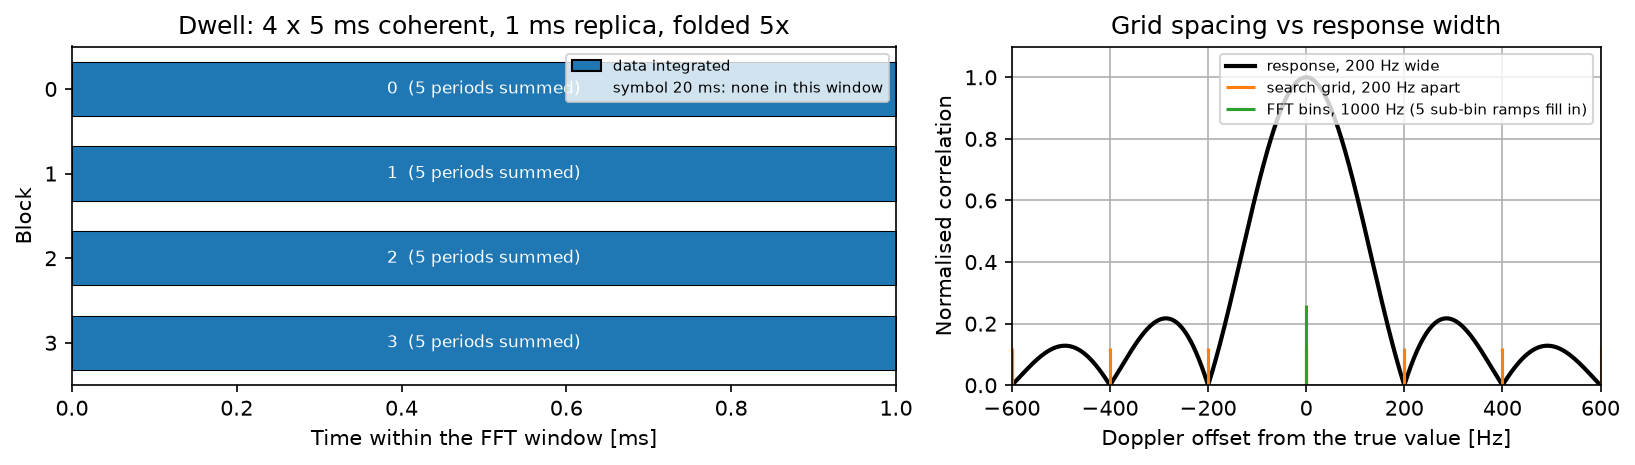

In [5]:
acq_config = bpsk_acquisition.AcquisitionConfiguration(
    coherent_duration_replica_ms=ACQ_SETTINGS["coherent_duration_replica_ms"],
    coherent_duration_sample_ms=ACQ_SETTINGS["coherent_duration_sample_ms"],
    num_blocks=ACQ_SETTINGS["num_blocks"],
    sample_rate=samp_rate,
    min_search_doppler_hz=-DOPPLER_SEARCH_HZ,
    max_search_doppler_hz=DOPPLER_SEARCH_HZ,
    fine_search=ACQ_SETTINGS["fine_search"],
)

# Shortest symbol among the signal's components -- the boundary the coherent blocks
# have to avoid straddling.  Dataless pilots have none.
symbol_periods = [
    c.symbol_period_ms
    for c in SIGNAL_ID(prn=1).code_set.components
    if c.symbol_period_ms is not None
]
shortest_symbol_ms = min(symbol_periods) if symbol_periods else None

fig = plt.figure(figsize=(11, 3.2), dpi=150)
utils.plotting.plot_acquisition_dwell_layout(
    fig, acq_config,
    symbol_period_ms=shortest_symbol_ms,
    # Acquisition does not know the symbol alignment; draw an arbitrary one.
    symbol_phase_ms=0.6 * (shortest_symbol_ms or 0.0),
)
plt.tight_layout()
plt.show()

## 4. Acquisition

One dwell of `num_blocks × coherent_duration_sample_ms`, read from
`START_OFFSET_MS`, searched against every PRN.

The cell first prints the **search resolution** — the worst-case error in the seed
acquisition will hand to tracking, in code phase (also as a range error in metres)
and in Doppler. With `fine_search` set, both the plain and refined figures are
shown, which is how to decide whether the extra passes are worth their cost.

Reading the table:

- The **detection threshold is one number for the whole sweep** — it depends only on
  the per-cell false-alarm rate and `num_blocks`, not on the satellite — so it is
  stated once in the header.
- Each row gives the peak in **dB above the expected noise level**: 0 dB is the
  noise floor, and the threshold is directly comparable.
- **Only detections get a row.** Without one, Doppler and code phase are meaningless
  — the peak is just the noise maximum — so the rest are counted under the table,
  with the range their peaks spanned.
- **Code phase is in chips, ambiguous modulo the length of the code that was
  correlated against**, and that modulus is in the column header — 204,600 for L5 on
  Q × NH20, 20,460 for L2C on CM, 10,230 for L1C on L1CP, 1,023 for L1 C/A. Chips
  rather than time because that is what the correlator counts in, and because half a
  chip means the same thing on every signal at any sample rate.

**Ambiguity resolution** then settles whatever the dwell could not locate. L2C
acquires on CM's 20 ms period, leaving CL's 1.5 s code 75× longer and unlocated, so
the 75 candidates are scored against the same dwell. L1 C/A and L5 have nothing left
and return an empty dict. L1C returns an empty dict too, but for a different reason:
its two components are both 10230 chips, so locating one locates the other — what
L1C leaves open is the *overlay* phase, settled during tracking.

Not every detection is real. At a loose `p_fa_total`, across 32 PRNs, expect a
spurious detection occasionally; it will fail to hold lock, which section 7 makes
visible.

In [6]:
signals = build_signals(SIGNAL_ID)
acq_code_params = build_acquisition_code_params(SIGNAL_ID, signals)

# Code phase in chips needs the acquisition code's chip rate, which belongs to the
# code rather than to the search configuration.
acq_chip_rate = next(iter(acq_code_params.values())).rate_chips_per_sec
print(acq_config.search_resolution_summary(acq_chip_rate))
print()

# Read the full coherent x non-coherent dwell.
acq_buffer_duration_ms = acq_config.acq_total_duration_ms
acq_buffer_size_samples = int(samp_rate * acq_buffer_duration_ms / 1e3)
byte_buffer = bytearray(
    sample_streaming.compute_sample_array_size_bytes(
        acq_buffer_size_samples, sample_params.bit_depth, sample_params.is_complex
    )
)
samples = np.zeros(acq_buffer_size_samples, dtype=np.complex64)
baseband_samples = np.zeros(acq_buffer_size_samples, dtype=np.complex64)

if acq_buffer_duration_ms > remaining_duration_ms:
    raise ValueError(
        f"the acquisition dwell is {acq_buffer_duration_ms:,.1f} ms but only "
        f"{remaining_duration_ms:,.1f} ms remain after START_OFFSET_MS. Lower the offset, "
        "or shorten the dwell (num_blocks x coherent_duration_sample_ms)."
    )

# Read -> decode -> mix to baseband -> remove DC, as in notebook 00 section 4, but
# starting from START_OFFSET_MS rather than the head of the file.
with open(collect_filepath, "rb") as f:
    f.seek(start_offset_bytes)
    num_bytes_read = f.readinto(byte_buffer)
if num_bytes_read < len(byte_buffer):
    raise RuntimeError(
        f"read {num_bytes_read:,} of {len(byte_buffer):,} bytes at offset "
        f"{start_offset_bytes:,}; the dwell runs past the end of the collect."
    )

sample_streaming.convert_to_complex64_samples(byte_buffer, samples, sample_params)
sample_streaming.mixdown_samples(
    samples,
    baseband_samples,
    samp_rate,
    initial_phase_cycles=0.0,
    freq_hz=inter_freq_hz,
)
baseband_samples -= np.mean(baseband_samples)

acq_results = bpsk_acquisition.run_acquisition(
    sample_block=baseband_samples,
    # Uptime zero is the first sample processed, not the first sample in the file,
    # so this stays 0.0 whatever START_OFFSET_MS is -- and the code phase it recovers
    # is on the same clock the tracking loops below will run on.
    sample_block_uptime_epoch_ms=0.0,
    acq_config=acq_config,
    code_parameters=acq_code_params,
    # Grid-wide, not per-cell: the right per-cell value depends on sample rate,
    # replica duration and Doppler range, so a hard-coded one stops meaning what it
    # did as soon as any of those change.  Sidak conversion happens inside.
    prob_false_alarm_total=ACQ_SETTINGS["p_fa_total"],
    print_progress=True,
    noise_var_method="abscorrvar",
)

acquired_signal_ids = sorted(
    sid for sid, result in acq_results.items() if result.signal_detected
)
print(f"\nAcquired ({SIGNAL_ID.signal_type_id}): {', '.join(acquired_signal_ids) or 'none'}")

# Resolve whatever the dwell could not locate (L2C's CL block); empty otherwise.
ambiguity_resolutions = resolve_acquisition_ambiguities(
    SIGNAL_ID, signals, acq_results, baseband_samples, acq_config,
)
if ambiguity_resolutions:
    tables.print_table(
        ["PRN", "block", "confidence", "status"],
        [[sid, r.best_index, f"{r.confidence:.2f}",
          "resolved" if r.resolved else "UNRESOLVED"]
         for sid, r in sorted(ambiguity_resolutions.items())],
        caption="\nLong-code ambiguity, scored against the same dwell:",
    )

Search grid: code phase 0.205 chips/bin (5.0 Msps), Doppler 200.0 Hz/bin
  plain search    -> code phase +/-0.102 chips (+/-30.0 m), Doppler +/-100.0 Hz
  fine search (delay x2, Doppler x2) -> code phase +/-0.051 chips (+/-15.0 m), Doppler +/-50.0 Hz



Detection threshold: 9.13 dB above noise (p_fa 1e-05 over 250,000 cells/PRN)

Detected signals show  coarse => fine.

  PRN             SNR [dB]          Doppler [Hz] Code phase [chips, mod 1,023]
  ----- ------------------ --------------------- -----------------------------


  G02         18.2 => 20.9        -1200 => -1100        791.597 =>     791.495
  G06         21.4 => 21.6        -1800 => -1800        514.569 =>     514.671
  G09         10.7 => 11.9        -1800 => -1700        857.479 =>     857.479
  G13         10.9 => 11.0        +2400 => +2400        846.839 =>     846.839
  G17         19.0 => 19.4        +2200 => +2200        691.957 =>     692.059
  G19         21.2 => 21.9        +2200 => +2100        473.444 =>     473.342
  G25           9.3 => 9.3          +200 => +200        654.515 =>     654.515
  25 PRN(s) below threshold, peaks 7.9-8.8 dB (loudest G28 at 8.8)

Acquired (GPS_L1CA): G02, G06, G09, G13, G17, G19, G25


## 5. Acquisition peaks

The table says *what* was found; this says how good it looks. One curve per acquired
satellite: correlation power against code delay, at that satellite's own peak
Doppler bin, with delay measured relative to its own peak so the shapes line up.
Power is in dB above the expected noise level — the same scale as the SNR column —
so each noise floor sits at 0 dB and each peak reads its own SNR. The dashed line is
the detection threshold.

**A real acquisition** is a sharp peak at delay 0, far above the line, falling to a
flat floor within about a chip either side. **A false one** is a low, shapeless bump
that barely clears it — a distinction the table alone does not make.

**The axis is delay, increasing to the right**, and the labels above it say which end
is which: left of the peak is a replica that arrives *earlier* than the signal, right
of it one that arrives *later*. Worth stating because the correlation grid itself is
indexed by code phase, which runs the opposite way — a signal delayed by `d` chips
peaks at index `L − d` of an `L`-chip code — so the plot negates it to get a delay
axis. The two differ only in sign and nothing about a single curve reveals which you
are looking at.

**Multipath lives in this dimension.** A reflection is always *delayed* relative to
the direct path, so it can only add energy on the **right**, and it shows as asymmetry
about zero — a shoulder on the late side, or a broadened, flattened peak — rather than
as a change in peak height. Resolution is set by the front end: at a couple of samples
per chip the ideal ±1 chip triangle spans only a handful of points.

> **Do not read every asymmetry as multipath.** At low samples-per-chip the true peak
> almost never lands exactly on a sample, so its two neighbours are unequal purely from
> where the sampling grid fell — and that lands either way at random, differing in sign
> from one satellite to the next. Real multipath skews late *consistently*, across
> satellites and across time. One dwell cannot tell them apart; a sequence of dwells can.

> This cell needs the full code-delay axis, which `run_acquisition` keeps by default
> (`save_corr_doppler_window_bins=1` narrows the *Doppler* axis only).

> **For `GpsL1C` this plot looks different, and should.** A BPSK peak is a single
> triangle about two chips wide at its base. BOC(1,1)'s main peak is three times
> narrower — it crosses zero at ±1/3 chip — and is flanked by negative side lobes
> reaching −0.5 at ±0.5 chip, which come back up to side peaks further out. On a
> power scale those appear as two shoulders either side of the main peak, roughly
> 6 dB down. That is the BOC signature, not a defect: the sharper peak is why L1C
> ranges more precisely than C/A on the same carrier. It is also the hazard — a
> delay loop can settle on a side peak and track happily half a chip (~150 m) away
> from the truth. Section 6 is about avoiding that.

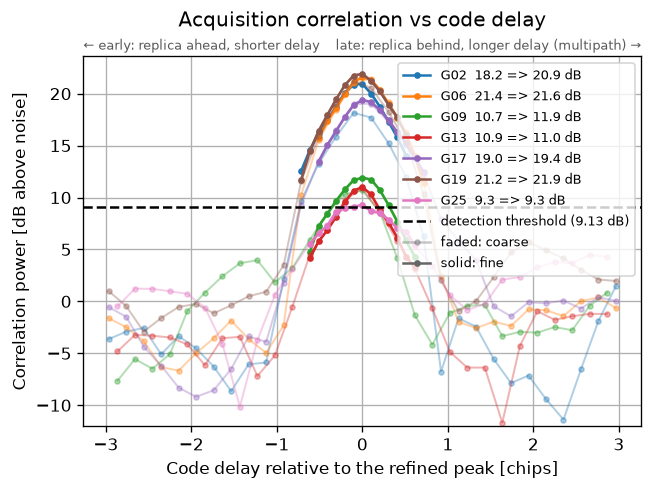

In [7]:
fig = plt.figure(figsize=(6, 4), dpi=120)
utils.plotting.plot_acquisition_code_phase_slices(fig, acq_results)
plt.show()

## 6. Tracking

One channel per acquired satellite, seeded from its acquisition result, then the collect
is streamed buffer by buffer. Each channel correlates one 1 ms interval at a time —
whatever the signal's own code period is — folds `COHERENT_DURATION_MS` of them into an
epoch (wiping off the overlay as it goes), and runs its discriminators once per epoch:

- **DLL** — normalised early-minus-late over correlators at ±`EPL_chip_spacing`.
- **PLL** — Costas phase discriminator on the carrier component, four-quadrant once that
  component is a confirmed dataless pilot.
- **FLL** — frequency error over the epoch. Coarser than the PLL but unambiguous over a
  much wider range, so tracking starts here.

### 6.1 Where epochs start

Acquisition seeds an arbitrary code phase, so an epoch grid begun there could straddle a
symbol boundary — which cancels the data components. Epochs therefore **open on a symbol
boundary**: a code phase that is a multiple of the symbol period, using the shortest
symbol among *all* components rather than the one the loops run on. That is stronger than
anchoring on the epoch length, since only this puts epoch zero on symbol zero and lets
navigation symbols be read straight off the epoch index. A 1 ms epoch is exempt.

The boundary is located in *code phase*, so acquisition must have recovered symbol phase
for it to be a true one — L5 through the NH20 counter, L2C through CM's 20 ms period,
L1C through L1CD's 10 ms code period. **L1 C/A is the exception:** a 1 ms code under a
20 ms data bit says nothing about where the bit begins, so `utils.nav.bitsync` histograms
where prompt sign changes fall across the twenty candidate phases and takes the peak — a
bit can only change sign at a boundary, so every other phase collects noise alone. Every
epoch records whether that succeeded, in `bit_synced`, and `utils.nav.symbols` refuses a
long-epoch grid that was never anchored: such a grid sits an unknown 0–19 ms from the bit
lattice, and the only symptom downstream is a pseudorange wrong by a whole number of
milliseconds — 300 km, on a fix that otherwise converges and looks healthy.

### 6.2 Why every channel opens at 1 ms

The reason is the FLL, not the data. Acquisition leaves a Doppler residual of up to half
a search bin, and the frequency discriminator wraps at ±1/4T (±1/2T once a pilot drops
Costas) — so a channel opened at 10 ms has a pull-in range of only ±25–50 Hz and can
begin with its residual *outside* the range of the loop meant to remove it. At 1 ms that
range is ten times wider and the coherent loss is negligible.

The extension fires once the carrier reaches PLL **and** the grid has a symbol boundary
to anchor to — cheapest mechanism first: a code period that is itself a symbol (**L2C**,
**L1C**), an overlay's phase (**L5**), or a measured bit boundary (**L1 C/A**). It then
waits for the next boundary rather than switching immediately, which is lossless: the
1 ms epochs keep producing output right up to it. Loop gains are retuned in the same step
and the carrier loop may move onto the pilot; both show as a change in point density in
section 7. The target is `COHERENT_DURATION_MS`, clamped to 10 ms on L5 and L1C and
20 ms on L1 C/A and L2C.

### 6.3 The double estimator, on BOC signals

A BOC signal is a code *multiplied by* a subcarrier, and a conventional channel
correlates against the product with one delay. That coupling is where the side peaks come
from, and narrowing the early/late taps does not fix it — it only shrinks the region from
which the loop pulls in correctly.

The **double estimator** gives the two factors their own delays and runs a loop on each:

| | rides | slope | ambiguity |
|---|---|---|---|
| **code loop** | the plain code triangle | 1 | none — one peak, a chip wide |
| **subcarrier loop** | the subcarrier | ≈ 6.4 | repeats every **0.5 chip** |

Neither is enough alone: the code loop is unambiguous but shallow, the subcarrier loop is
six times more sensitive but cannot tell which repeat it is on. The coarse estimate picks
the repeat and the fine one supplies the precision —

    delay = τ_subcarrier + T · round((τ_code − τ_subcarrier) / T)      T = 0.5 chip

— the same move as resolving a carrier-phase integer against a code pseudorange.

*If this looks like cheating, it should.* The two factors leave the satellite with the
**same** delay, so estimating them separately is deliberate over-parameterisation. A
conventional receiver searches only the line `τ_code = τ_subcarrier`, and it is that
slice through the 2-D surface, not the signal, that has the extra peaks. (`T` is half a
chip rather than a whole one because the discriminator combines magnitudes and so cannot
tell the +1 peak at zero from the −1 peak half a chip later. The code loop therefore has
to hold ±0.25 chip, which it does easily, and can be narrowed to 0.5 Hz because it now
carries only the ambiguity.)

Due to Hodgart, Blunt and Unwin, *"Double Estimator: A New Receiver Principle for
Tracking BOC Signals"*, Inside GNSS, Spring 2008. The alternative that keeps one delay is
**bump jumping** (Fine and Wilson, ION NTM 1999): very-early and very-late taps notice
the loop has settled on a side peak and jump it. That recovers from false lock; the
double estimator cannot have one.

**Overlay sync on L1C** is the slow part: L1CO is 1800 symbols long, so the channel tracks
first and then correlates a couple of seconds of prompts against all 1800 hypotheses in
one FFT. Success drops Costas wrapping — worth about 6 dB — but buys no extra epoch
length, which had already reached L1CD's 10 ms symbol.

In [8]:
if not acquired_signal_ids:
    raise RuntimeError("No signals acquired; cannot start tracking.")

buffer_size_samples = int(samp_rate * BUFFER_DURATION_MS / 1e3)
num_buffers_to_process = TRACK_DURATION_MS // BUFFER_DURATION_MS
output_capacity = TRACK_DURATION_MS // COHERENT_DURATION_MS  # one row per epoch

# Actual tracked duration can fall short of TRACK_DURATION_MS: num_buffers_to_process
# is a floor division, so any remainder shorter than one buffer is dropped.
actual_track_duration_ms = num_buffers_to_process * BUFFER_DURATION_MS
tables.print_fields(
    [("channels", f"{len(acquired_signal_ids)}: {', '.join(acquired_signal_ids)}"),
     ("coherent integration", f"{COHERENT_DURATION_MS} ms (cap)"),
     ("tracking", f"{actual_track_duration_ms:,} ms from {start_offset_ms / 1e3:,.1f} s"),
     ("buffers", f"{num_buffers_to_process:,} x {BUFFER_DURATION_MS} ms")],
)

tracking_loop_params = tracking_channel.TrackingLoopParameters(
    PLL_bandwidth_hz=20.0,
    FLL_bandwidth_hz=50.0,
    coherent_duration_ms=COHERENT_DURATION_MS,
    prompt_corr_circ_length_threshold=0.9,  # prompt coherence needed for FLL -> PLL
    **DLL_SETTINGS,                         # set per-signal in the config cell
)

tracking_channels = create_tracking_channels(
    SIGNAL_ID,
    signals=signals,
    acquisition_results=acq_results,
    tracking_signal_ids=acquired_signal_ids,
    loop_params=tracking_loop_params,
    output_capacity=output_capacity,
    start_mode_pll=START_TRACKING_IN_PLL_MODE,
    ambiguity_resolutions=ambiguity_resolutions,
)

buffers_processed = 0
with sample_streaming.FileSampleStream(
    collect_filepath,
    sample_params,
    buffer_size_samples,
    start_sample=start_sample,  # same point in the file acquisition searched
) as sample_stream:
    buffers = sample_stream.sample_buffer_generator()
    # mininterval: a progress bar that redraws many times a second leaves hundreds
    # of separate output chunks in the saved notebook.  Two seconds is still live.
    progress = tqdm(buffers, total=num_buffers_to_process, mininterval=2.0)
    for i_buffer, buffer_samples in enumerate(progress):
        if i_buffer >= num_buffers_to_process:
            break

        # Advance the mixing phase with elapsed time so the sinusoid stays continuous
        # across buffers; resetting it each buffer would inject a phase step for the
        # PLL to chase.
        uptime_ms = i_buffer * BUFFER_DURATION_MS
        sample_streaming.mixdown_samples(
            buffer_samples,
            buffer_samples,
            samp_rate,
            initial_phase_cycles=inter_freq_hz * (uptime_ms * 1e-3),
            freq_hz=inter_freq_hz,
        )

        # SampleBuffer carries the timestamp each channel uses to work out which
        # samples fall inside its current correlation interval.
        sample_buffer = sample_streaming.SampleBuffer(
            samples=buffer_samples,
            start_uptime_ms=uptime_ms,
            samp_rate=samp_rate,
        )
        for adapter in tracking_channels.values():
            adapter.process_sample_buffer(sample_buffer)
        buffers_processed += 1

# The stream ends quietly at end of file, so a run that ran out of collect looks
# exactly like one that finished -- say which it was.
if buffers_processed < num_buffers_to_process:
    print(f"Reached end of file after {buffers_processed * BUFFER_DURATION_MS:,} ms of "
          f"the {actual_track_duration_ms:,} ms requested;\n"
          "lower START_OFFSET_MS or TRACK_DURATION_MS.")
else:
    print("Tracking complete")

/Volumes/JX_SSD/Desktop/CU_Boulder/Summer_2026/HERON/gps-tracking-example/utils/signal_interfaces.py:948: RuntimeWarning: extending to 5 ms caps loop bandwidths at 20 Hz (Bn*T <= 0.1); narrowing FLL_bandwidth_hz 50 -> 20 Hz at the handover. The longer accumulation is what pays for the narrower loop, but the loop after the extension is not the one configured.
  channel = tracking_channel.TrackingChannel(


  channels              7: G02, G06, G09, G13, G17, G19, G25
  coherent integration  5 ms (cap)
  tracking              120,000 ms from 0.0 s
  buffers               1,200 x 100 ms



  0%|          | 0/1200 [00:00<?, ?it/s]


  4%|▍         | 52/1200 [00:02<00:44, 25.85it/s]


  9%|▉         | 106/1200 [00:04<00:41, 26.52it/s]

...


 91%|█████████ | 1090/1200 [00:40<00:04, 26.71it/s]


 95%|█████████▌| 1144/1200 [00:42<00:02, 26.77it/s]


100%|█████████▉| 1198/1200 [00:44<00:00, 26.83it/s]


100%|██████████| 1200/1200 [00:44<00:00, 26.85it/s]

Tracking complete


## 7. Tracking results

Three views of one satellite. Change `plot_sig_id` to compare a strong channel against a
weak one.

### 7.1 Prompt correlators, per component

One row per code component, I and Q together. A locked channel puts essentially all of
each component's power on **one** axis and leaves the other at zero. Which axis depends
on that component's carrier phase relative to the one the loop is tracking: the component
the loop runs on lands on **I**; one in phase quadrature lands on **Q** (GPS L5 is
exactly this — with the loop on the Q pilot, L5I's power shows up in the imaginary part);
components sharing a carrier phase both land on I (L2C's `CM` and `CL`, L1C's `L1CD` and
`L1CP`).

The number of bands on that axis says what the component carries: a **data component**
shows two, and the transitions are navigation symbols; a **dataless pilot** shows one.
Before its overlay is stripped a pilot flips sign like data and looks like a data
component. And because every component shares one epoch, a component whose magnitude
collapses while its siblings stay healthy is straddling its own symbol boundary — what
the anchoring in 6.1 exists to prevent.

### 7.2 Code delay and Doppler

**Code phase and code delay are not the same quantity**, and the difference is worth
being exact about because everything downstream rests on it.

`code_phase_ms` is what tracking reports: the satellite's own transmit-time coordinate,
advancing at very nearly one millisecond per millisecond of receiver time. What has
physical meaning as a range is the **code delay**:

    code delay = uptime − code phase

receiver time minus transmit time — the transit time plus the receiver clock offset,
which is a pseudorange in milliseconds. Two things follow. The two quantities move in
*opposite* directions as range changes, since a satellite moving away makes its
transmit-time coordinate fall further behind receiver time. And the delay is tiny beside
either of them — tens of milliseconds against a number growing without bound — which is
why the plot shows the delay **referenced to its first epoch**, as a residual in metres.
The residual is the part that reflects the satellite actually moving.

**The code delay is ambiguous, and comes out negative if you leave the ambiguity out.**
Acquisition seeds the code phase at the phase it measured, so `uptime − code_phase`
starts at exactly *minus* that — and the seed is only ever known modulo the period of
the code acquisition correlated against. Adding one period back puts the delay in
`[0, ambiguity)`, which is what the legend reports:

| Signal | Acquired on | Code delay known modulo |
|---|---|---|
| L1 C/A | `CA` | **1 ms** |
| L2C | `CM`, then CL resolved across 75 blocks | **1.5 s** |
| L5 | `Q` × NH20 | **20 ms** |
| L1C | `L1CP` | **10 ms** |

Only L2C's is longer than a transit time, and there the delay is not merely positive but
is the transit time itself (plus the receiver clock offset) — every satellite lands in
the 67–86 ms band a GPS orbit allows, overhead to horizon. On the others the modulus is
shorter than the transit, so the delay is that transit *wrapped*: real, measurable, and
not yet a range. Notebook `02` removes the ambiguity for good, using a decoded time of
week to pin the code phase origin.

Read the pair as line-of-sight dynamics — a steady Doppler of a few kHz produces a delay
ramp of a fraction of a chip per second. But they are **related by construction, not
independently measured**: this tracker slaves the code rate to the carrier,
`code_rate = (1 + doppler / f_carrier)`, so the delay residual is the integral of Doppler
over the carrier frequency. The plot is for seeing that dynamic, and for seeing both
break together when a channel loses lock — not for a code-carrier consistency check.

### 7.3 Carrier loop coherence and C/N0

**Circular length** is the coherence of the recent prompt history — the magnitude of the
mean unit phasor. It is ~1 when the prompt phase is steady and falls toward 0 as it
scatters, and it is the statistic the channel uses to decide the FLL has pulled the
frequency error in far enough to hand over. Epochs are coloured by which loop filtered
them, with the threshold and handover marked. Expect a short FLL stretch, a crossing,
then PLL for the rest of the run. Sagging back toward the threshold under PLL is a
channel about to lose lock; one that never leaves FLL never locked at all.

> **The dip just after the handover is expected — it is not a loss of signal.** The FLL
> controls frequency only, so it hands over holding whatever phase error it has; the PLL
> drives that to zero over the next ten or so epochs, and it is the *sweep* of phase
> during that correction, not any drop in power, that spreads the phasors. Prompt
> magnitude in 7.1 is flat straight through.

**The green trace is C/N0**, on the right-hand axis, by the variance summing method from
the second and fourth moments of the prompt magnitude. It differs in kind from the
coherence trace: it runs on **1 ms intervals** rather than epochs, because C/N0 is a
density; and it should be **flat** for a locked channel, since it measures how much
signal is arriving rather than how well the loop is holding phase. It does not dip at the
handover, and if it does dip the signal genuinely faded.

45+ dB-Hz is a strong open-sky signal, and tracking starts to struggle below roughly
30 dB-Hz. These are **per component**, so a two-component signal shows each about 3 dB
below the combined figure.

> **Set the C/N0 period well below `TRACK_DURATION_MS`.** The default window is 1000 ms
> with 50% overlap, so one estimate arrives every 500 ms. A one-second run yields a
> single point and looks broken.

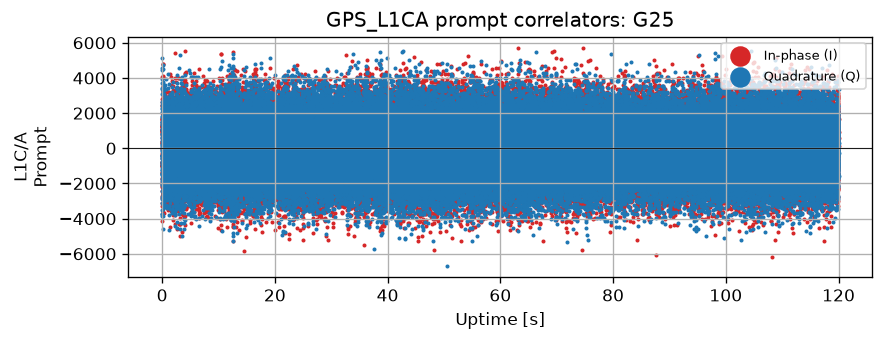

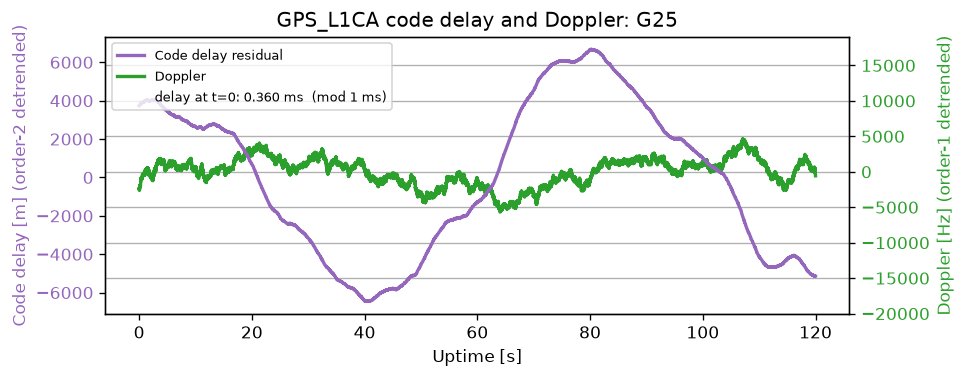

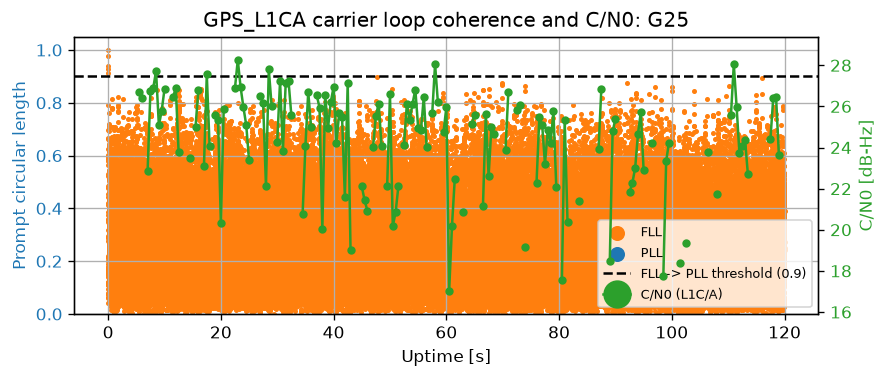

In [9]:
plot_sig_id = acquired_signal_ids[-1]  # index into acquired_signal_ids to change
adapter = tracking_channels[plot_sig_id]
num_components = len(adapter.signal.component_names)

# 7.1 Prompt correlator, one row per component, I and Q together.
fig = plt.figure(figsize=(8, 2.6 * num_components), dpi=120)
utils.plotting.plot_prompt_components(
    fig, adapter, plot_sig_id,
    title=f"{SIGNAL_ID.signal_type_id} prompt correlators: {plot_sig_id}",
)

# 7.2 Line-of-sight dynamics: code delay residual against carrier Doppler.
# The delay is `uptime - code_phase`, and that is only known modulo the period
# acquisition pinned -- extended by the long-code resolution where there was one, which
# on L2C turns CM's 20 ms into CL's 1.5 s.  Without it the reported delay is negative.
fig2 = plt.figure(figsize=(8, 3), dpi=120)
utils.plotting.plot_code_delay_and_doppler(
    fig2, adapter, plot_sig_id,
    title=f"{SIGNAL_ID.signal_type_id} code delay and Doppler: {plot_sig_id}",
    code_delay_detrend_order=2,
    doppler_detrend_order=1,
    ambiguity_ms=bpsk_acquisition.code_phase_ambiguity_ms(
        acq_results[plot_sig_id], ambiguity_resolutions.get(plot_sig_id)
    ),
)

# 7.3 Carrier loop coherence and VSM C/N0.
fig3 = plt.figure(figsize=(8, 3), dpi=120)
utils.plotting.plot_prompt_circ_length(
    fig3, adapter, plot_sig_id,
    title=f"{SIGNAL_ID.signal_type_id} carrier loop coherence and C/N0: {plot_sig_id}",
)

plt.show()

## 8. Save the tracking results

Notebook `02` forms a navigation solution from these channels, and tracking is by far
the slower half: minutes to produce, seconds to use. So the outputs go to disk here
and notebook `02` reads them back.

What is written is the *history* — the per-epoch arrays, the tap layout that gives
them meaning, and the collect and signal they came from — not a resumable tracking
channel. The sample stream is gone; the measurements are the point. Recording which
collect and signal produced it lets notebook `02` refuse a stale file rather than
quietly forming pseudoranges from the wrong satellite.

The name carries the span tracked, so a run over a different span is a different result
rather than a newer one. Set the same `START_OFFSET_MS` and `TRACK_DURATION_MS` in
notebook `02` to load this one back.

**Reading the table.** `span [s]` should be the same for every channel, since they all
saw the same samples. The epoch counts should not be, and they are split the way notebook
`02` splits them — by epoch length, and by the loop that filtered them — because those
two are different conditions and the mismatch is the useful part:

- **A long epoch in FLL should never appear.** The extension requires PLL and the mode
  never reverts, so such a column existing at all means a channel extended without
  locking.
- **A 1 ms epoch in either mode is normal.** `1 ms PLL` is the waiting room: the carrier
  is locked and the channel is still looking for a symbol boundary — on L1 C/A, that is
  where bit synchronisation happens (section 6.1).

So the columns read left to right as a story: pulling the carrier in, waiting to find
where a symbol starts, then everything after both. A channel whose count sits almost
entirely in `1 ms FLL` never locked at all; one stuck in `1 ms PLL` locked its carrier and
never found its boundary. Either way it contributes nothing to notebook `02`, which can
only read symbols off the long-epoch grid.

`of capacity` reaching 100 is different again: output stops being written when the buffer
fills, so that channel is shorter than it looks, and the warning underneath says which.

In [27]:
tracking_path = tracking_io.tracking_path(
    utils.environment_variables.get_outputs_path(),
    experiment_name,
    collect_id,
    SIGNAL_ID.signal_type_id,
    START_OFFSET_MS,
    # Built from the configured TRACK_DURATION_MS rather than the actual one, so
    # notebook 02 can rebuild the name from its own configuration.  The two differ by
    # less than one buffer, which disappears in the rounding to whole seconds.
    TRACK_DURATION_MS,
    experiment_collect_ids=channel.sibling_collect_ids,
)
tracking_io.save_tracking_results(
    tracking_path,
    tracking_channels,
    collect_id=collect_id,
    signal_type_id=SIGNAL_ID.signal_type_id,
    samp_rate=samp_rate,
    experiment_name=experiment_name,
    acquisition_results=acq_results,
)

# Epochs crossed by length and loop mode, the same breakdown notebook 02 opens with --
# built by the same helper, so the two cannot drift apart.
epoch_headers, epoch_counts = tracking_io.epoch_duration_mode_columns(
    {sid: adapter.outputs for sid, adapter in tracking_channels.items()}
)

rows, at_capacity = [], []
for sid, adapter in sorted(tracking_channels.items()):
    outputs = adapter.outputs
    count = outputs.output_index
    uptime = outputs.uptime_epoch_ms[outputs.valid]
    span_s = (uptime[-1] - uptime[0]) * 1e-3 if len(uptime) > 1 else 0.0
    # Truncated, not rounded: one epoch short of the cap is not 100%, and printing
    # it as 100 next to a warning that correctly did not fire reads as a bug.
    rows.append(
        [sid, f"{span_s:,.1f}"]
        + epoch_counts[sid]
        + [f"{int(100.0 * count / outputs.capacity)}"]
    )
    # Outputs stop being written once capacity is reached, silently.  A run that hit
    # the cap is shorter than it looks, and notebook 02 would then form pseudoranges
    # over a window that ends early for no visible reason.
    if count >= outputs.capacity:
        at_capacity.append(f"{sid} (hit the {outputs.capacity:,}-epoch cap)")

tables.print_table(
    ["PRN", "span [s]"] + epoch_headers + ["of capacity [%]"],
    rows,
    caption=f"Wrote {tracking_path}",
)
if at_capacity:
    print("\nWARNING -- output stopped early, so these channels are shorter than they")
    print("look. Raise output_capacity or shorten TRACK_DURATION_MS:")
    for note in at_capacity:
        print(f"  {note}")

Wrote /Volumes/JX_SSD/Desktop/CU_Boulder/Summer_2026/HERON/OUTPUTS/tracking/20210612_121000_011501_HI/RX7_GPS_L1CA_0-120s.h5
  PRN  span [s]  1 ms FLL  1 ms PLL  5 ms PLL  of capacity [%]
  ---  --------  --------  --------  --------  ---------------
  G02     120.0        10     1,013    23,795               20
  G06     120.0        10     1,013    23,795               20
  G09     120.0       160     1,018    23,764               20
  G13     120.0       283     1,016    23,740               20
  G17     120.0        10     1,010    23,795               20
  G19     120.0        12     1,013    23,794               20
  G25     120.0   119,999         0         0               99


---

## Exercises

1. **Loop bandwidth.** Set `PLL_bandwidth_hz` to 5, then 50, and compare the prompt
   scatter and the Doppler trace.
2. **Start in PLL.** Set `START_TRACKING_IN_PLL_MODE = True` and see which channels
   fail to pull in from the seed Doppler error printed in section 4.
3. **Fine search.** Set `FINE_SEARCH = None` and compare the printed error ranges,
   the reported code phase (it should move by up to half a sample), and the runtime.
4. **A weaker satellite.** Point `plot_sig_id` at the last entry of
   `acquired_signal_ids`.
5. **Elsewhere in the collect.** Move `START_OFFSET_MS` and re-acquire. Geometry,
   gain and interference all change over a pass, so the set of satellites found need
   not be the same.
6. **The same sky on several bands.** If your experiment recorded more than one band
   simultaneously, `SIGNAL_ID` selects which of those files is read. Run each and
   compare which satellites appear — the sets usually differ, and the reason is
   usually the antenna rather than the signals.
7. **BOC side peaks.** Run `plot_acquisition_code_phase_slices` for an L1C signal
   (synthetically, as `tests/test_l1c.py` builds one, if your front end is too narrow
   for BOC(6,1)) and find the shoulders at ±0.5 chip. Then work out how far a *single*
   delay lock loop would have to be pulled off before early and late magnitudes
   stopped telling it which way to go.
8. **Turn the second loop off.** With `SIGNAL_ID = GpsL1C`, set
   `subcarrier_bandwidth_hz` and `subcarrier_chip_spacing` to `0.0` in `DLL_SETTINGS`.
   That falls back to a single delay loop on the composite BOC peak. Predict first:
   does the loop fail to lock, lock somewhere wrong, or lock with more jitter? Then
   check against `plot_epl_magnitude_and_code_error`.

## Not covered here

Tracking yields carrier phase and code phase per satellite. A position fix
additionally needs the navigation message decoded, ephemerides evaluated, and the
pseudoranges solved — notebook `02`.

For L1C specifically: **bump jumping**, the very-early/very-late test that catches a
delay loop locked onto a BOC side peak, and **CNAV-2** decoding. L1C's end-to-end
behaviour is demonstrated in `tests/test_l1c.py`, and `tests/test_l1c_codes.py`
checks every generated code against the values IS-GPS-800J publishes for all
210 PRNs.